In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime
import xarray as xr


# workaround until galvani pip module can handle  EClab v11.5
cwd = os.getcwd()
os.chdir('/mpc/homes/fische_r/lib/python_playground') #path where BioLogic.py sits
import BioLogic 
os.chdir(cwd)

In [2]:
toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
EC_path = os.path.join(toppath, 'Electrochemistry', '02_EC_data')

## extract data from EC-lab files, combine same samples and put into netcdf4

In [19]:
def get_total_charge(Qraw):
    """
    works for negative currents throughout
    """
    Qraw = Qraw[np.isfinite(Qraw)] #check for failed measurements, typically aborted
    steps = np.argwhere((Qraw- np.roll(Qraw, 1))>0).flatten()
    Q = Qraw.copy()
    # for i in range(1,len(steps)):
    #     step = steps[i]
    #     correction = Qraw[steps[1]-1]
    #     for j in range(1, i):
    #         correction = correction + Qraw[steps[j]-1]
    #     Q[step:] = Qraw[step:] + correction
    for i in range(1,len(steps)):
        step = steps[i]
        Q[step:] = Qraw[step:] + Q[step-1]
    return Q

def mpr_to_numpy(path, Q0, A=0.1): #[A] = cm2
    mpr_file = BioLogic.MPRfile(path)
    starttimestamp = mpr_file.timestamp.timestamp()
    time = mpr_file.data['time/s']
    timestamps = starttimestamp + time
    labels = ['freq/Hz', 'Re(Z)/Ohm', '-Im(Z)/Ohm', '<I>/mA', '<Ewe>/V', '(Q-Qo)/mA.h']
    clean_labels = ['t_utc:s', 'freq:Hz]', 'Re(Z):Ohm.cm2', 'Im(Z):Ohm.cm2', 'I:mA/cm2', 'E:V', 'Q:As/cm2', 'time:s']
    data = np.zeros((len(clean_labels),len(time)))
    data[0,:] = timestamps
    i = 1
    for label in labels:     
        try:
            x =  mpr_file.data[label]
        except:
            if label == '<Ewe>/V':
                x =  mpr_file.data['Ewe/V']
            else:
                x = np.zeros(len(time))
            
        if label=='<I>/mA':
            x = x/A
        if label=='(Q-Qo)/mA.h':
            x = get_total_charge(x)
            x = x/A/1000*3600 #convert mA.h to As/cm2
            x = x + Q0
            Q0 = x.min()
        if label=='Re(Z)/Ohm' or label=='-Im(Z)/Ohm':
            x = x*A
        data[i,:] = x
        i = i+1
    return data, Q0, clean_labels

def sort_mpr_files(samplefolder, mprfiles):
    files = [BioLogic.MPRfile(os.path.join(samplefolder,file)) for file in mprfiles]
    # for file1, file2 in zip(files,mprfiles):  #find corrupt EClab files if necessary
    #     print(file2)
    #     print(file1.timestamp.timestamp())
    timestamps = np.array([file.timestamp.timestamp() for file in files])

    t0s = []
    for file in files:
        if len(file.data['time/s'])>0:
            t0 = file.data['time/s'][0]
        else:
            t0 = -1
        t0s.append(t0)
    t0s = np.array(t0s)
    rels = t0s>=0
    # print(rels)
    timestamps = timestamps[rels] + t0s[rels]
    order = np.argsort(timestamps)
    mprfiles = np.array(mprfiles)
    mprfiles = list(np.array(mprfiles[rels])[order])
    return mprfiles


def EC_data_to_xarray(samplefolder):
    sample = os.path.split(samplefolder)[-1]
    files = os.listdir(samplefolder)

    mprfiles = [file for file in files if file[-3:]=='mpr']
    mprfiles = sort_mpr_files(samplefolder, mprfiles)
    Q0 = 0
    file_arrays = []
    for file in mprfiles:
        data, Q0, clean_labels = mpr_to_numpy(os.path.join(samplefolder,file), Q0)
        file_arrays.append(data)
    data = np.concatenate(file_arrays, axis=1)
    data[-1,:] = data[0,:] - data[0,0]

    # create xarray dataset
    time = data[-1,:]
    dataset = xr.Dataset({'t_utc': ('time', data[0,:])},
                         coords = {'time': data[-1,:]}
                        )
    dataset['t_utc'].attrs['unit'] ='s'
    dataset['time'].attrs['unit'] ='s'
    dataset.attrs = {'sample': sample, 'sample path': samplefolder, 'files': mprfiles}
    for i in range(1,len(clean_labels)-1):
        splitlabel = clean_labels[i].split(':')
        name = splitlabel[0]
        unit = splitlabel[1]
        dataset[name] = ('time', data[i,:])
        dataset[name].attrs['unit'] = unit

    datapath = os.path.join(samplefolder, sample+'_extracted_EC.nc')
    dataset.to_netcdf(datapath)
    return dataset
        
        

In [24]:
series = ['A','B', 'C', 'D', 'E','F','G', 'Z']

for ser in series:
    serpath = os.path.join(EC_path, ser+'_series')
    samples = os.listdir(serpath)
    for sample in samples:
        print(sample)
        # if sample in ['D_3', 'F_3']: continue
        dataset = EC_data_to_xarray(os.path.join(serpath, sample))

A_13
A_13__02_GEIS_C01.mpr
1696576601.385
A_13_b__01_PEIS_C01.mpr
1696577450.852
A_13_e__02_GEIS_C01.mpr
1696578091.46
A_13_e__01_PEIS_C01.mpr
1696578091.46
A_13_h__01_PEIS_C01.mpr
1696578355.944
A_13__01_PEIS_C01.mpr
1696576601.385
A_13_f__01_PEIS_C01.mpr
1696578208.316
A_13_i__02_GEIS_C01.mpr
1696584515.445
A_13_g__02_GEIS_C01.mpr
1696578287.146
A_13_i__01_PEIS_C01.mpr
1696584515.445
A_13_c__01_PEIS_C01.mpr
1696577668.394
A_13_j__02_GEIS_C01.mpr
1696584778.148
A_13_h__02_GEIS_C01.mpr
1696578355.944
A_13_c__02_GEIS_C01.mpr
1696577668.394
A_13_d__01_PEIS_C01.mpr
1696577771.21
A_13_b__02_GEIS_C01.mpr
1696577450.852
A_13_g__01_PEIS_C01.mpr
1696578287.146
A_13_f__02_GEIS_C01.mpr
1696578208.316
A_13_d__02_GEIS_C01.mpr
1696577771.21
A_13_j__01_PEIS_C01.mpr
1696584778.148
A_8
A_8__01_PEIS_01_PEIS_C01.mpr
1696341438.371
A_8_b_01_PEIS_C01.mpr
1696339358.819
A_8__01_PEIS_02_GEIS_C01.mpr
1696341438.371
A_8__02_GEIS_C01.mpr
1696338845.877
A_8_b_02_GEIS_C01.mpr
1696339358.819
A_8__01_PEIS_C01.mpr


## plot raw data for all samples

/tmp/ipykernel_557129/2594959041.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


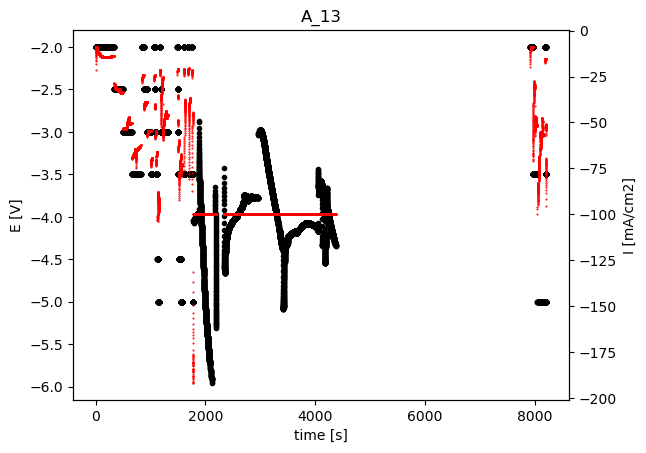

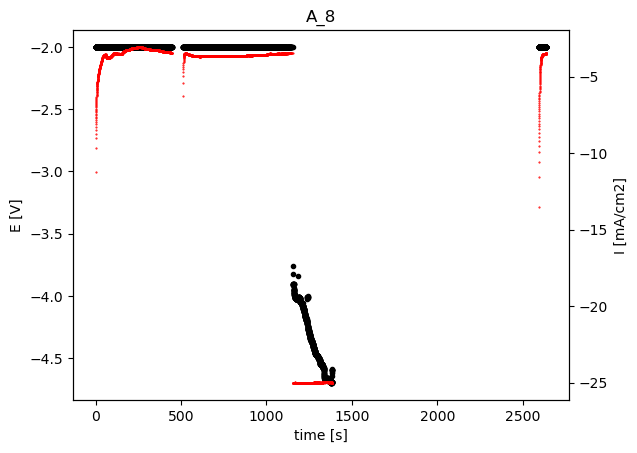

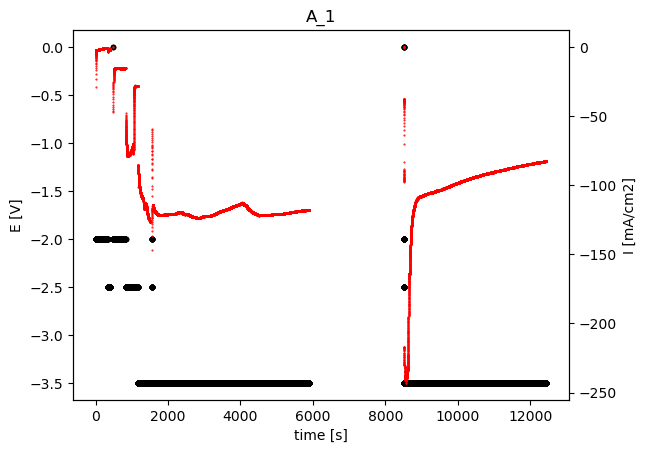

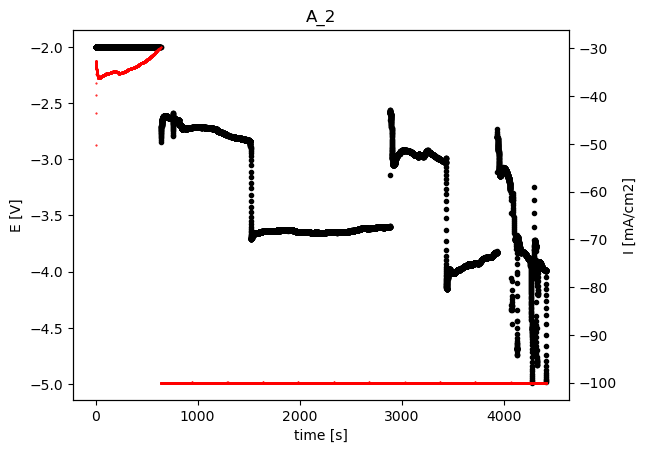

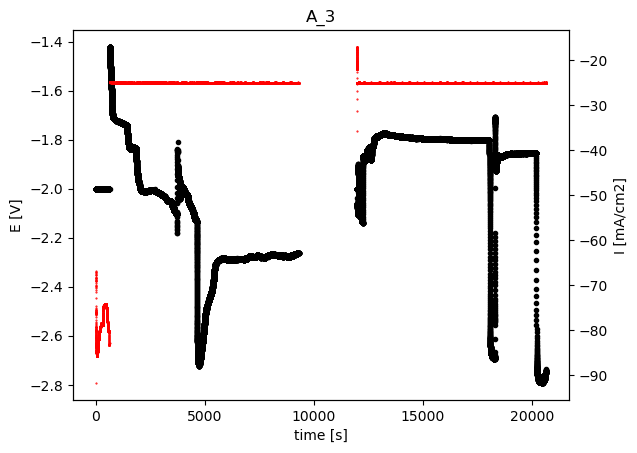

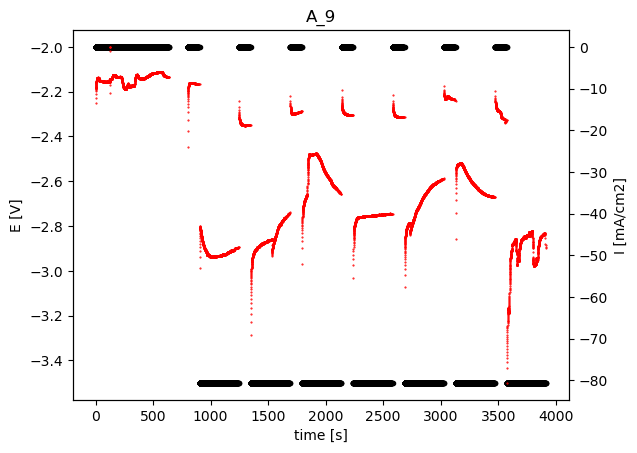

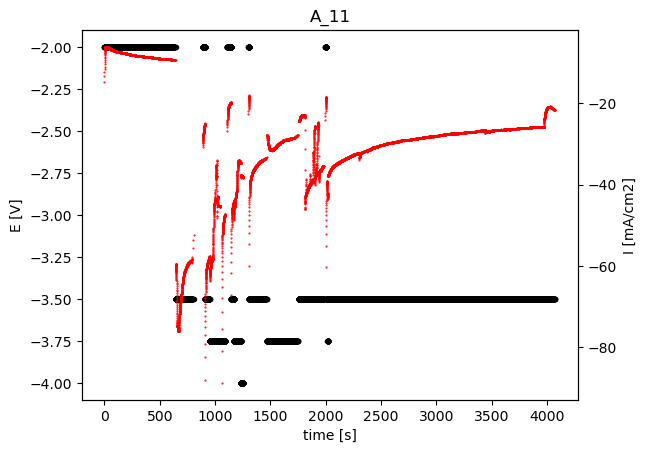

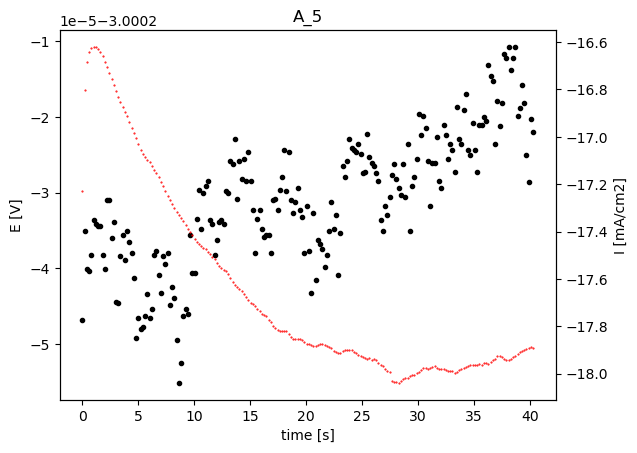

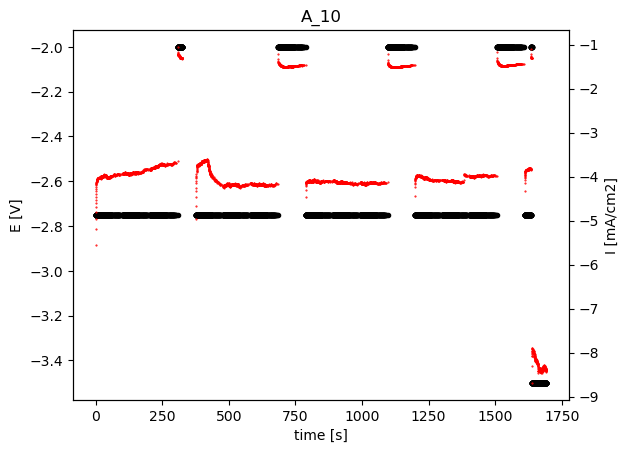

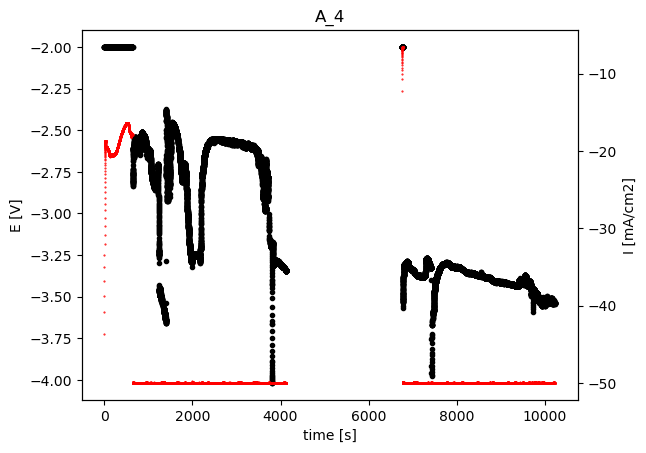

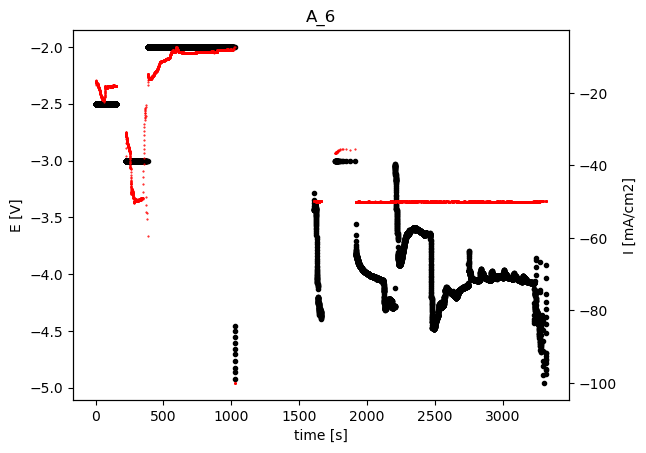

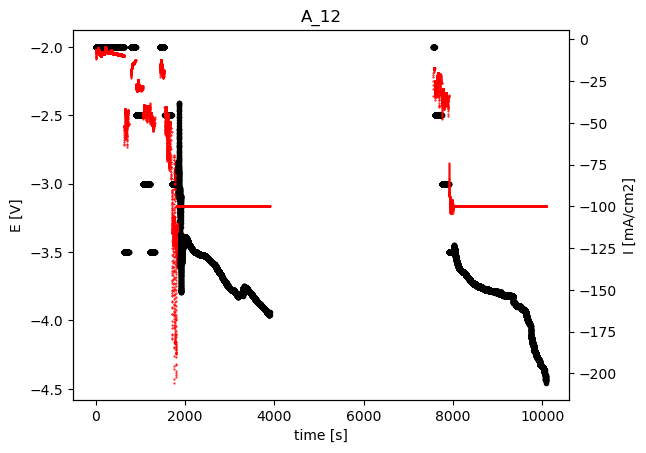

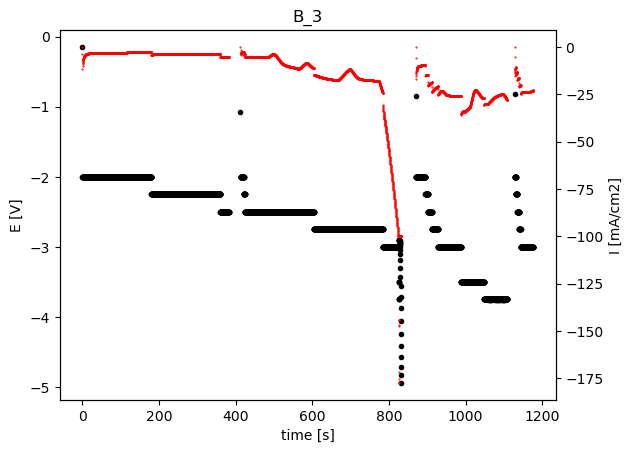

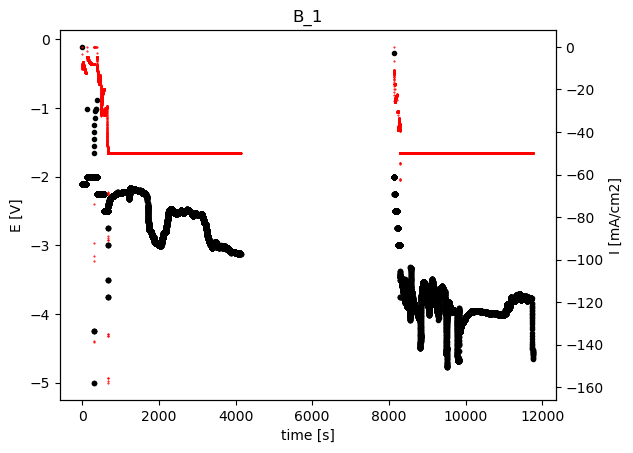

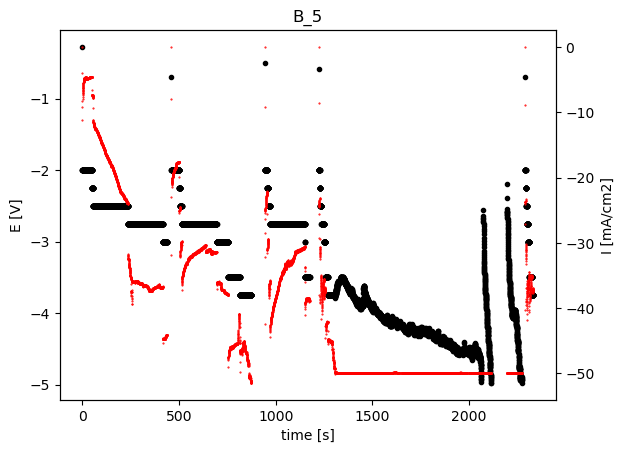

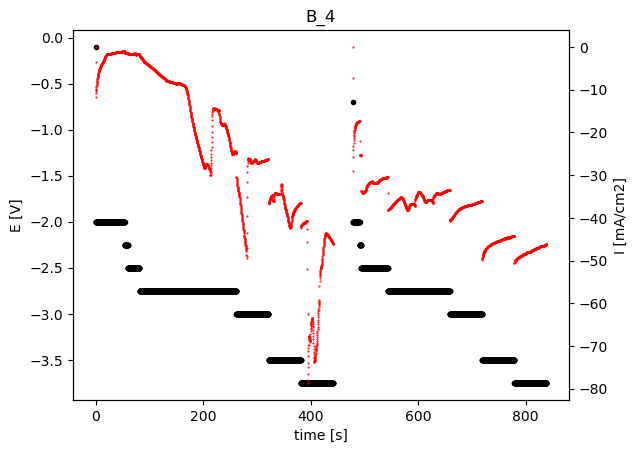

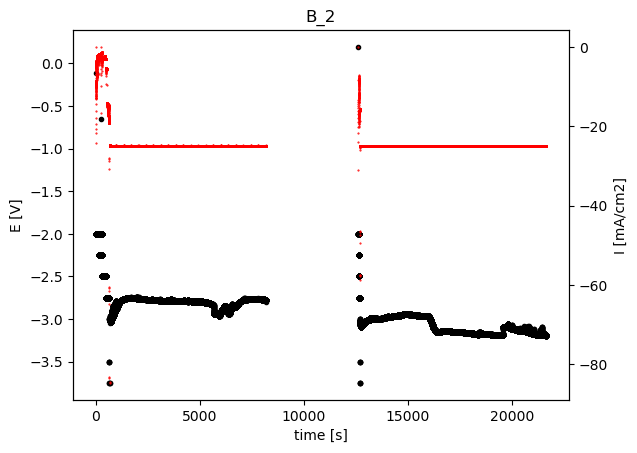

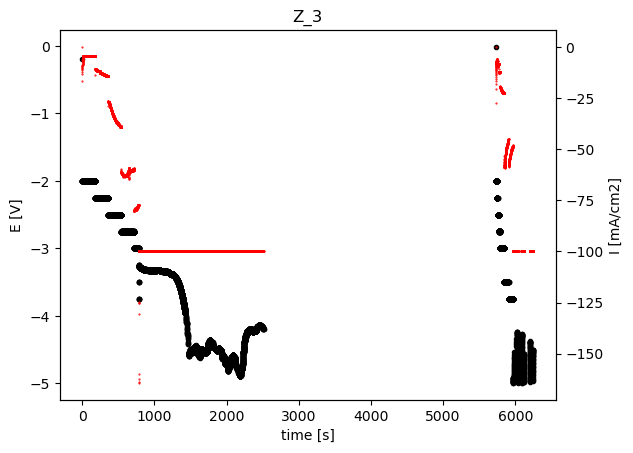

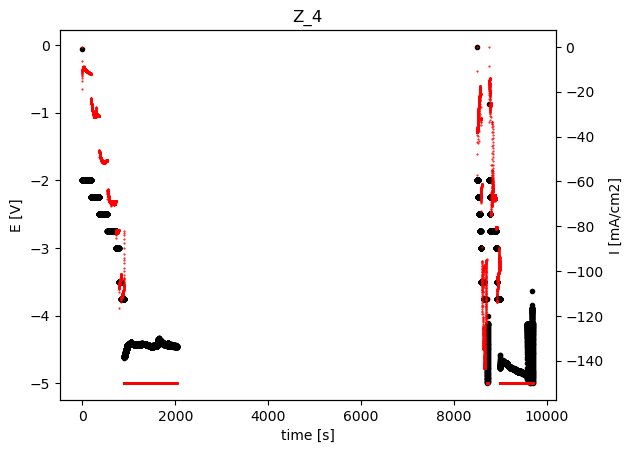

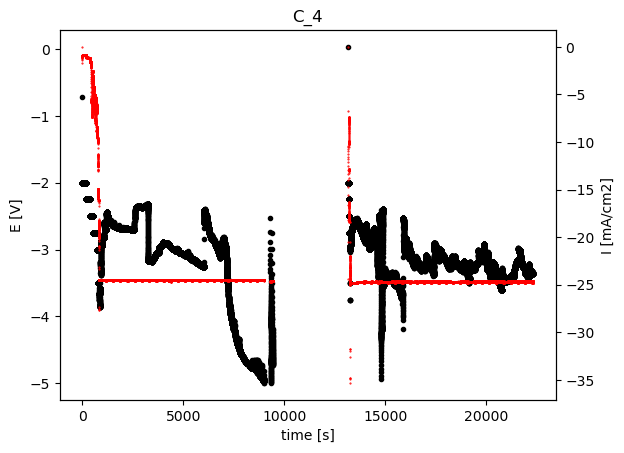

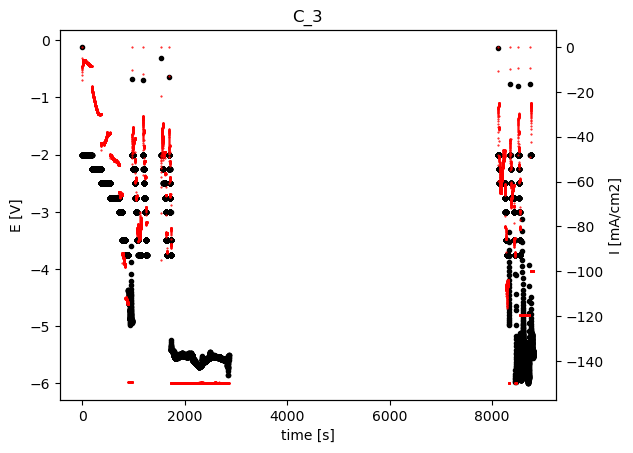

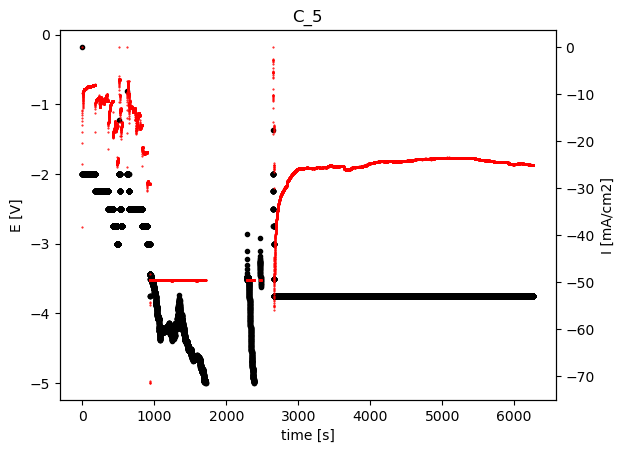

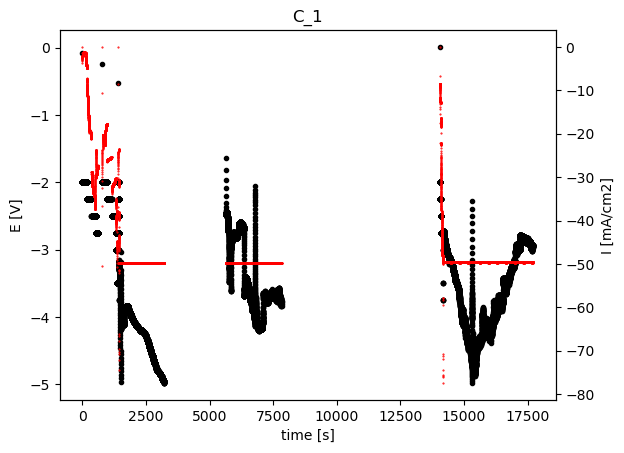

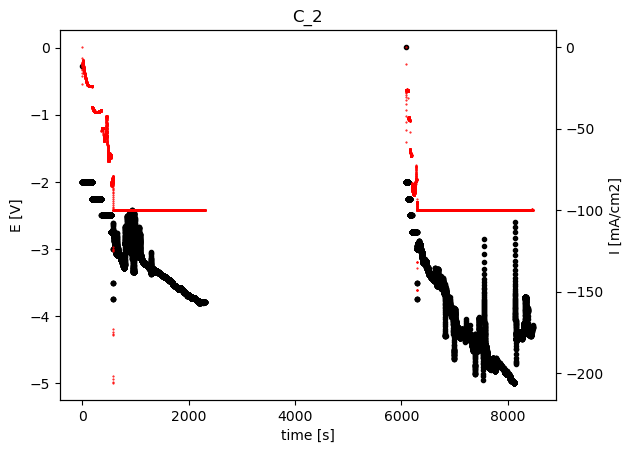

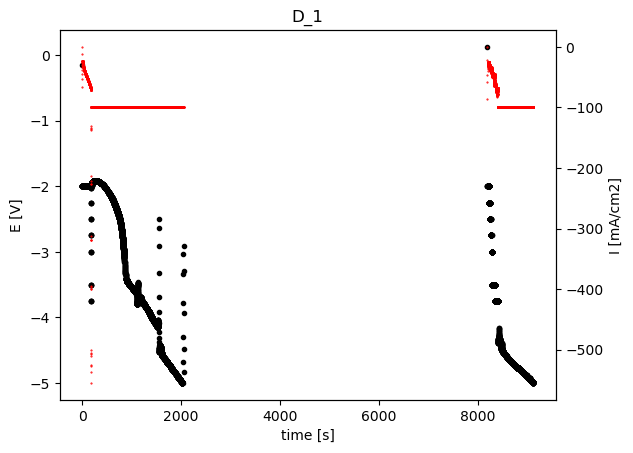

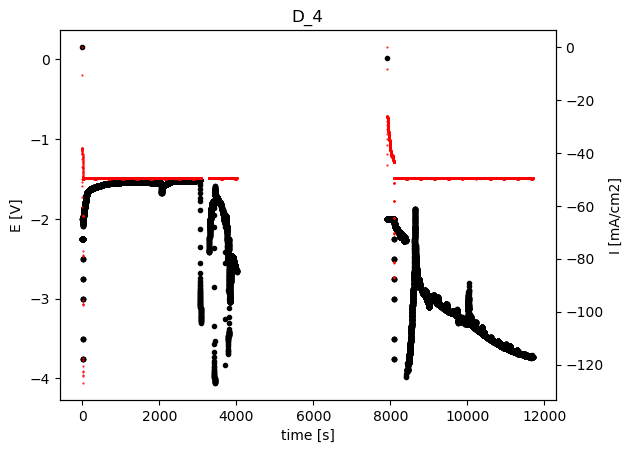

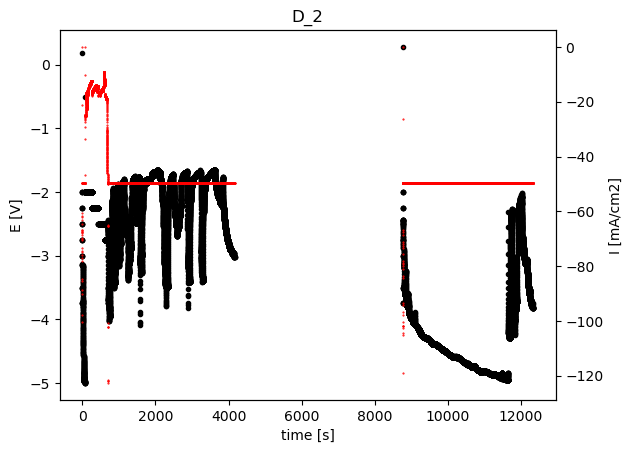

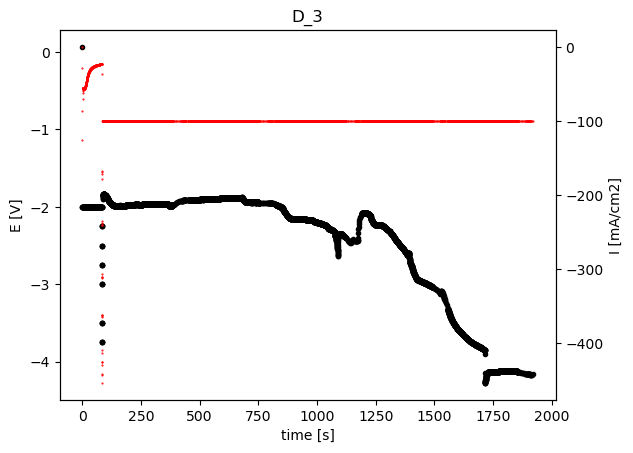

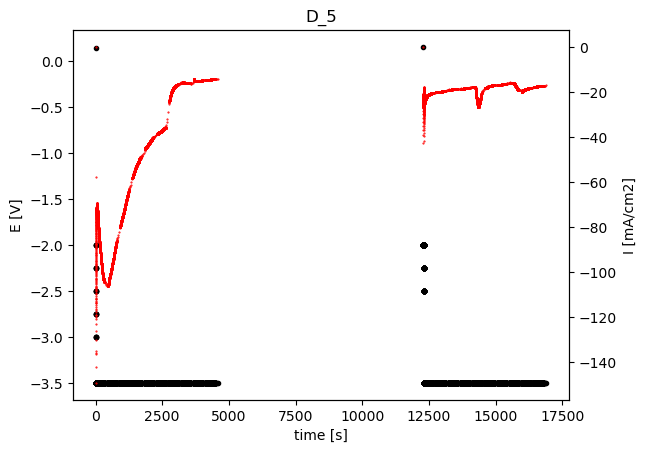

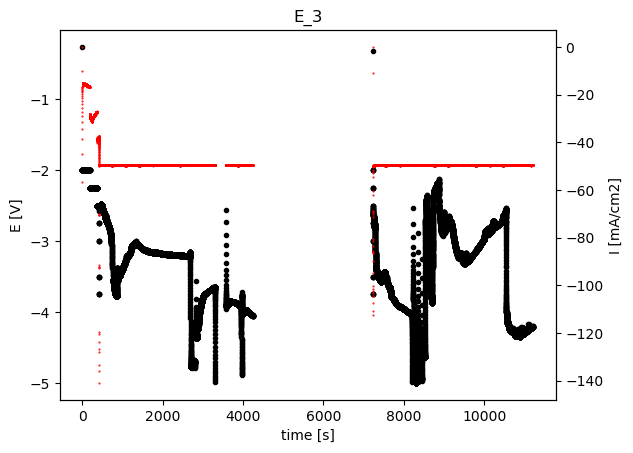

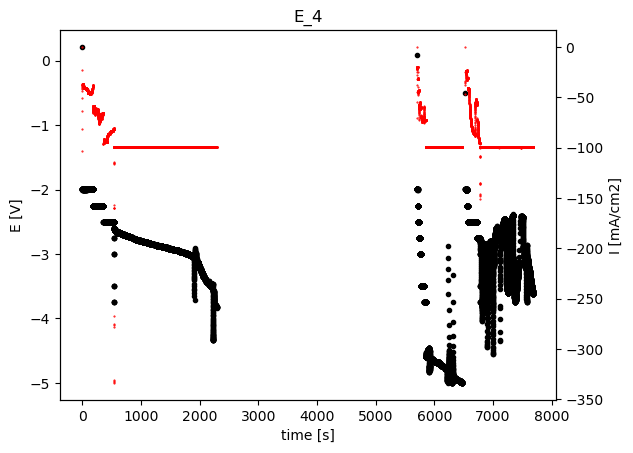

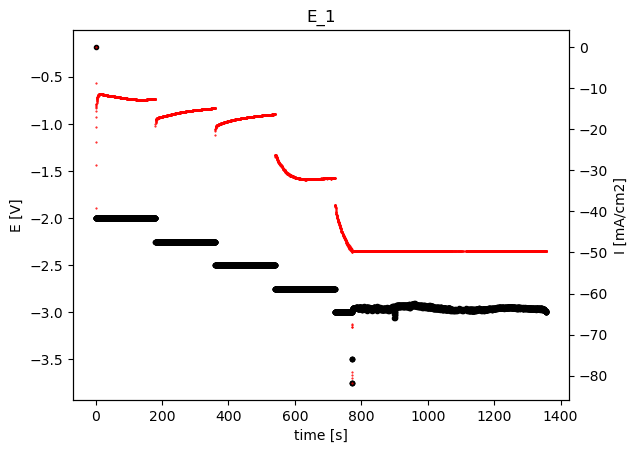

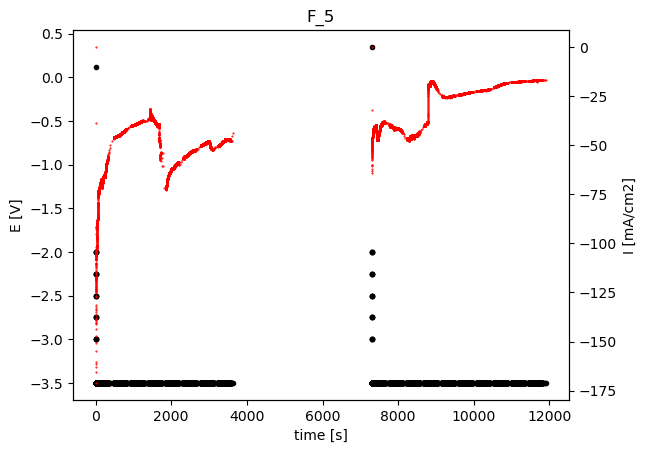

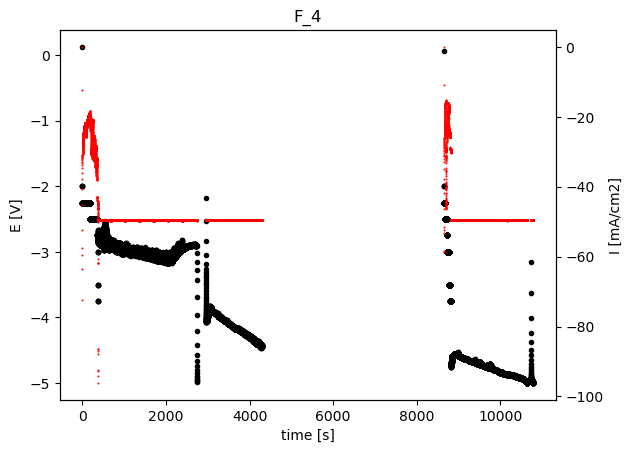

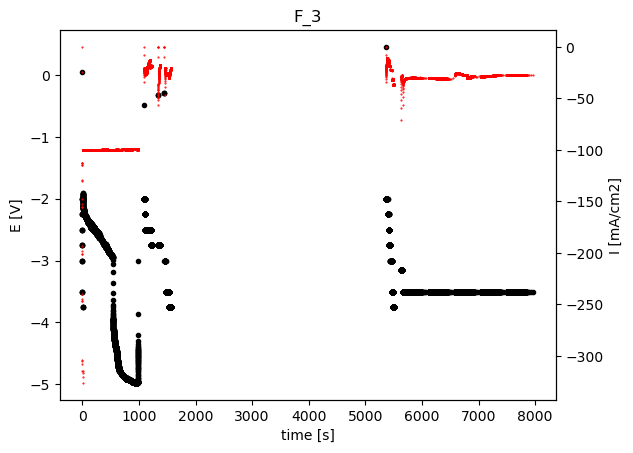

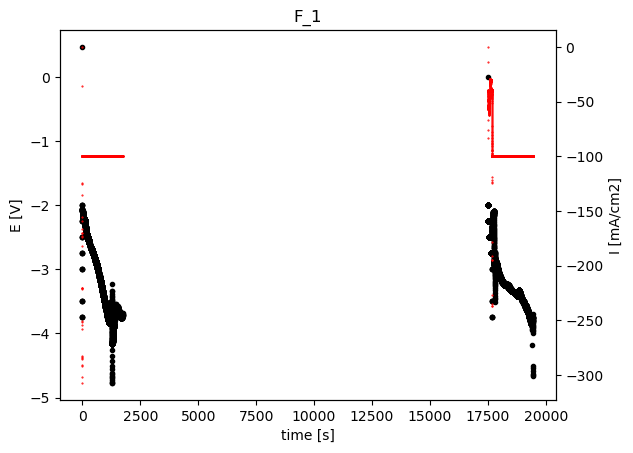

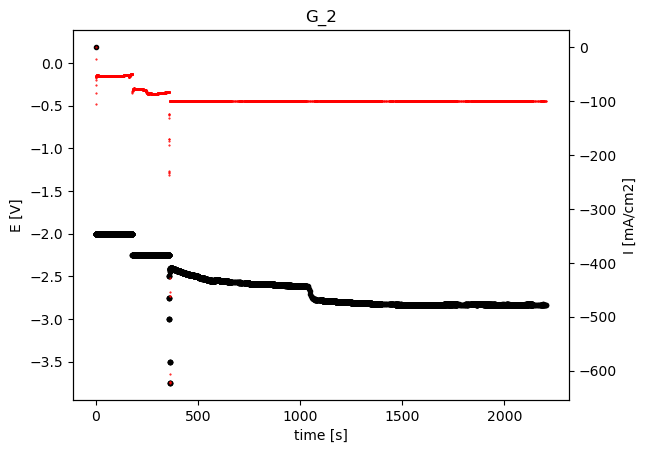

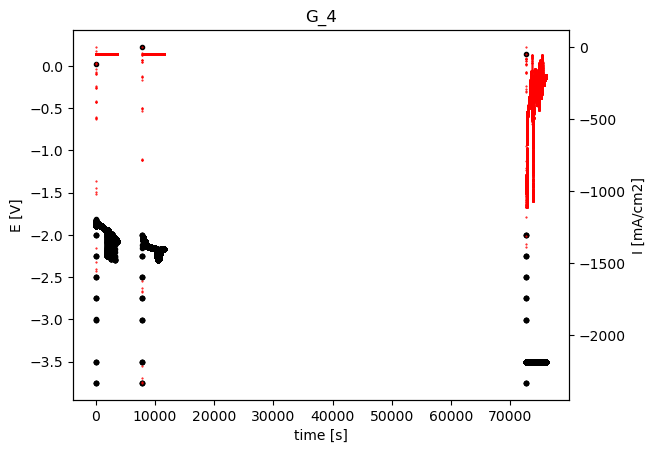

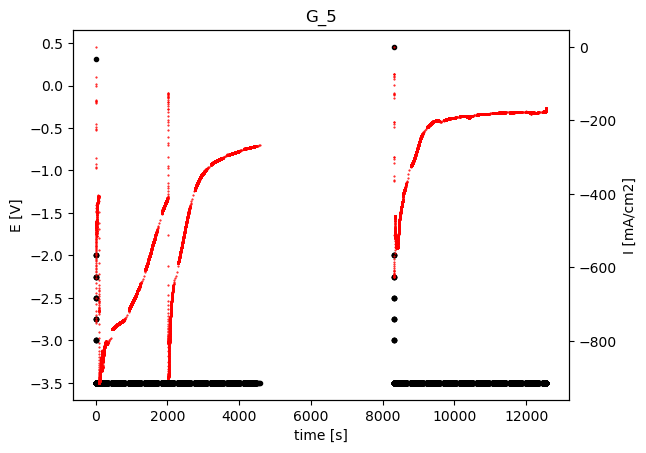

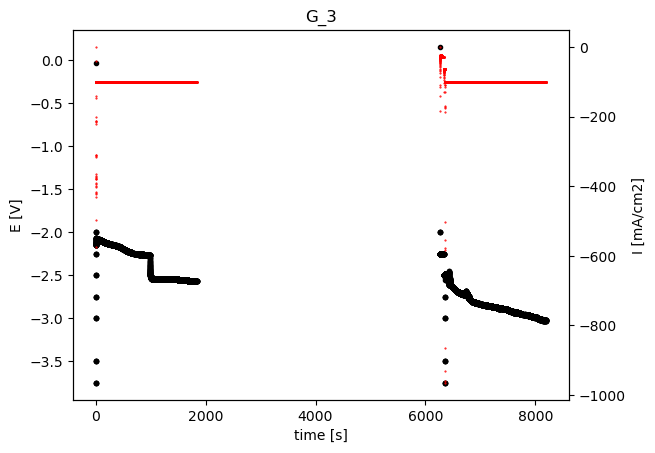

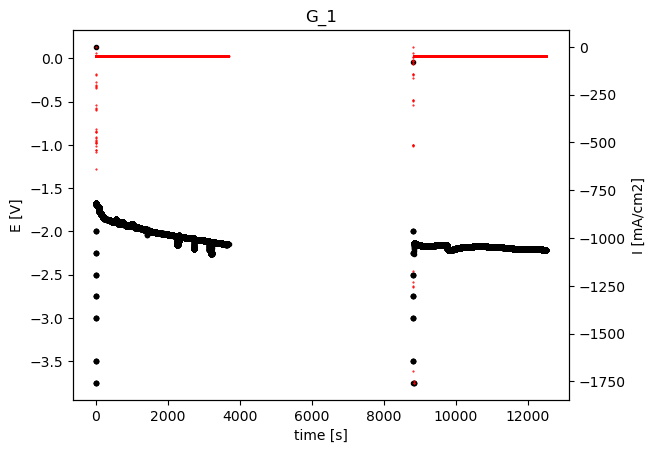

In [50]:
series = ['A', 'B','Z', 'C', 'D', 'E', 'F', 'G']

for ser in series:
    serpath = os.path.join(EC_path, ser+'_series')
    samples = os.listdir(serpath)
    for sample in samples:
        # print(sample)
        # if not sample == 'G_1': continue
        ncpath = os.path.join(serpath, sample, sample+'_extracted_EC.nc')
        data = xr.load_dataset(ncpath)
        fig, ax = plt.subplots()
        x_label = 'time'
        y1_label = 'E'
        y2_label = 'I'
        ax.plot(data[x_label], data[y1_label], 'k.')
        ax.set_xlabel(x_label+' ['+data[x_label].attrs['unit']+']')
        ax.set_ylabel(y1_label+' ['+data[y1_label].attrs['unit']+']')
        ax2 = ax.twinx()
        ax2.plot(data[x_label], data[y2_label], 'r.', markersize=1)
        ax2.set_ylabel(y2_label+' ['+data[y2_label].attrs['unit']+']')

        # ax.set_ylim(-1,-3)
        # ax2.set_ylim(0,-100)
        plt.title(sample)

## plot voltage vs. charge for different current densities

In [51]:
current_25 = ['A_3', 'B_2', 'C_4']
current_50 = ['A_4', 'B_1', 'C_1', 'D_2', 'E_3', 'G_1', 'G_4']
current_50_special = ['A_6', 'C_5']
current_80_special = ['A_11', 'A_9', 'B_4'] + ['F_4']
current_100 = ['A_12', 'C_2', 'D_1', 'E_4', 'G_2', 'G_3', 'F_1'] + ['F_3']
current_150 = ['C_3']#, 'Z_4'] # Z_4 pretty damaged during assembly
current_high_special = ['A_13', 'A_11'] + ['F_5', 'G_5', 'D_5']
nitrogen = ['D_4', #at 50mA/cm2
           ]
ignored = ['D_3', #bad assembly, initially dry FAA leads to buckling after swelling --> fixed for later experiments form dry FAA by cutting opening and preswelling
          ]
const_3_5V = ['A_1', 'A_9', 'A_11', 'C_5', 'D_5', 'F_5', 'F_3', 'G_5']
clean_lists = [current_25, current_50, current_100, current_150]

In [47]:
def plot_voltage_vs_charge(sample, ax):
    serpath = os.path.join(EC_path, sample[0]+'_series')
    ncpath = os.path.join(serpath, sample, sample+'_extracted_EC.nc')
    data = xr.load_dataset(ncpath)
    color = 'k'
    if sample[0] in ['D']:
        color = 'r'
    if sample[0] in ['E']:
        color = 'b'
    if sample[0] in ['F']:
        color = 'g'
    if sample[0] in ['G']:
        color = 'y'
    x_label = 'Q'
    y1_label = 'E'
    ax.plot(-data[x_label], -data[y1_label],'.',  label = sample, color = color, markersize = 1)
    ax.set_xlabel(x_label+' ['+data[x_label].attrs['unit']+']')
    ax.set_ylabel(y1_label+' ['+data[y1_label].attrs['unit']+']')


def plot_current_vs_charge(sample, ax):
    serpath = os.path.join(EC_path, sample[0]+'_series')
    ncpath = os.path.join(serpath, sample, sample+'_extracted_EC.nc')
    data = xr.load_dataset(ncpath)
    color = 'k'
    if sample[0] in ['D']:
        color = 'r'
    if sample[0] in ['E']:
        color = 'b'
    if sample[0] in ['F']:
        color = 'g'
    if sample[0] in ['G']:
        color = 'y'
    x_label = 'Q'
    y1_label = 'I'
    ax.plot(-data[x_label], -data[y1_label],'.',  label = sample, color = color, markersize = 1)
    ax.set_xlabel(x_label+' ['+data[x_label].attrs['unit']+']')
    ax.set_ylabel(y1_label+' ['+data[y1_label].attrs['unit']+']')

Text(0.5, 1.0, '25 mA/cm2')

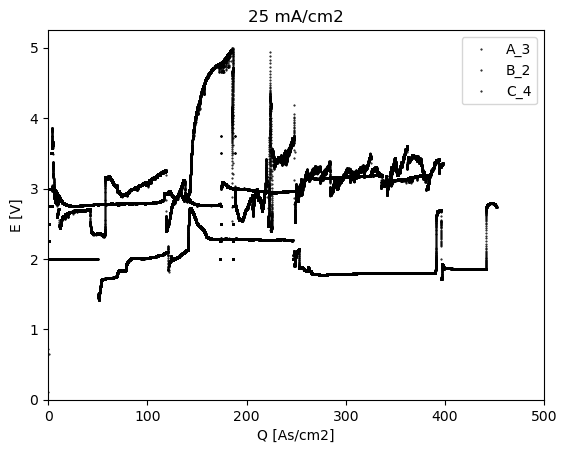

In [29]:
fig, ax = plt.subplots()
for sample in current_25:
    plot_voltage_vs_charge(sample,ax)
ax.set_xlim(0,500)
ax.set_ylim(0,5.25)
plt.legend()
plt.title('25 mA/cm2')

Text(0.5, 1.0, '50 mA/cm2')

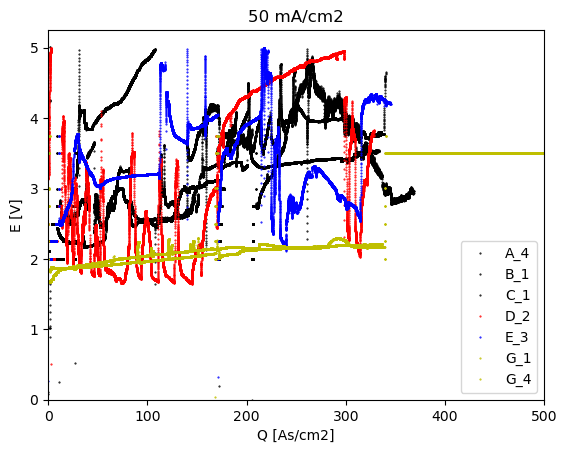

In [33]:
fig, ax = plt.subplots()
for sample in current_50:
    plot_voltage_vs_charge(sample,ax)
ax.set_xlim(0,500)
ax.set_ylim(0,5.25)
plt.legend()
plt.title('50 mA/cm2')

Text(0.5, 1.0, '100 mA/cm2')

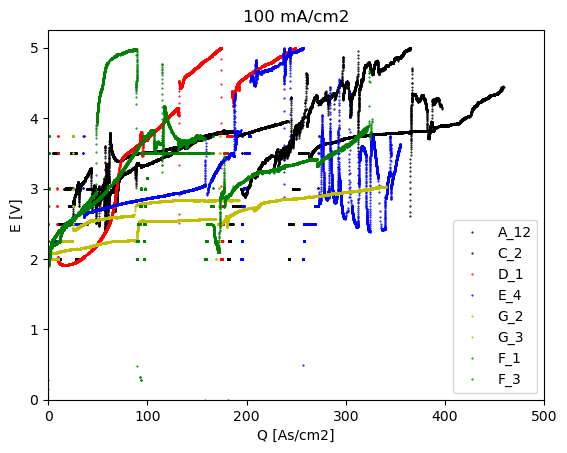

In [46]:
fig, ax = plt.subplots()
for sample in current_100:
    plot_voltage_vs_charge(sample,ax)
ax.set_xlim(0,500)
ax.set_ylim(0,5.25)
plt.legend()
plt.title('100 mA/cm2')

Text(0.5, 1.0, 'constant voltage 3.5V')

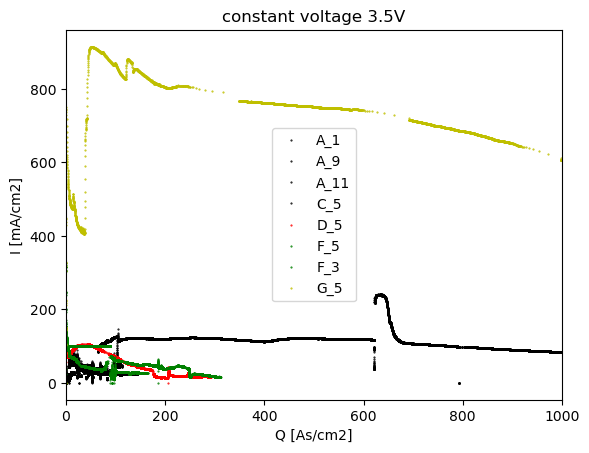

In [54]:
fig, ax = plt.subplots()
for sample in const_3_5V:
    plot_current_vs_charge(sample,ax)
ax.set_xlim(0,1000)
# ax.set_ylim(0,300)
plt.legend()
plt.title('constant voltage 3.5V')